In [ ]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import pandas as pd
import seaborn as sns

In [3]:
codelists = json.load(Path("../data/rsi-codelists-analysis.json").open())

In [ ]:
# normalise to hash-based slugs for versions
# some variables reference the same codelist version by hash or tag
normalised_version_slugs = {}
for codelist_version_slug in codelists:
    for codelist_version_slug in codelist_version_slug["versions"]:
        normalised_version_slugs[codelist_version_slug["slug"]] = (
            codelist_version_slug["slug"] + "/" + codelist_version_slug["hash"]
        )
        normalised_version_slugs[
            codelist_version_slug["slug"] + "/" + codelist_version_slug["hash"]
        ] = codelist_version_slug["slug"] + "/" + codelist_version_slug["hash"]

In [5]:
# load into dataframes
df_codelists = pd.DataFrame()
df_codelist_versions = pd.DataFrame()
for codelist in codelists:
    df_codelists = pd.concat(
        [
            df_codelists,
            pd.DataFrame([{k: v for k, v in codelist.items() if k != "versions"}]),
        ]
    )
    for version in codelist["versions"]:
        df_codelist_versions = pd.concat(
            [
                df_codelist_versions,
                pd.DataFrame(
                    [
                        {"codelist_slug": codelist["slug"]}
                        | version
                        | {"slug": normalised_version_slugs[version["slug"]]}
                    ]
                ),
            ]
        )
df_codelists.set_index("slug", inplace=True)
df_codelist_versions.set_index("slug", inplace=True)

## Overall counts from OpenCodelists
### Codelists with at least one under review/published version:

In [6]:
len(df_codelists)

7896

In [7]:
df_codelists.groupby("coding_system").count()["name"].sort_values()

coding_system
readv2        25
null          34
opcs4         84
ctv3         676
dmd          695
bnf          959
icd10       1326
snomedct    4097
Name: name, dtype: int64

### Under review/published versions

In [8]:
len(df_codelist_versions)

12019

In [9]:
df_codelist_versions.merge(
    df_codelists, left_on="codelist_slug", right_index=True
).groupby("coding_system").count()["name"].sort_values()

coding_system
readv2        25
null          37
opcs4        120
ctv3         766
dmd         1097
bnf         1160
icd10       1512
snomedct    7302
Name: name, dtype: int64

In [10]:
df_job = pd.read_csv(
    "../data/All.jobs-data-2025-11-10.18_25_26.csv", index_col="sha"
).rename(columns={"_status": "status"})

## Job data

In [11]:
len(df_job)

24523

In [12]:
df_job.groupby("status").count()["url"].sort_values()

status
pending              1
running              4
nothing_to_do        7
unknown             53
failed            9013
succeeded        15445
Name: url, dtype: int64

In [13]:
# load ehrl codelist usage file, restructure for convenience/performance
ehrql_codelists = json.load(Path("../data/ehrql_codelists.json").open())
signatures_to_shas = defaultdict(set[str])
signatures_to_projects = dict()
for project, hashes in ehrql_codelists["projects"].items():
    for sha, signature in hashes.items():
        signatures_to_shas[signature].add(sha)
        signatures_to_projects[signature] = project
df_signatures_to_shas = pd.DataFrame(
    [{"signature": k, "sha": sha} for k, v in signatures_to_shas.items() for sha in v]
)
df_repo_signatures = pd.DataFrame(
    [{"repo": v, "signature": k} for k, v in signatures_to_projects.items()]
)

## Repo signatures
Unique combinations of variable definitions in a repo

In [14]:
len(df_repo_signatures)

249

In [15]:
# signatures per repo. "Count" is number of repos
df_repo_signatures.groupby("repo").count().describe()

,signature
count,45.000000
mean,5.533333
std,6.900593
min,1.000000
25%,1.000000
50%,2.000000
75%,8.000000
max,29.000000


In [16]:
# link ehrql codelist data and job server data
df_variables = pd.DataFrame()  # id, sig, file, name
df_jobs_variables = pd.DataFrame()  # sha, var_id
df_variables_codelists = pd.DataFrame()  # var_id, codelist_version_slug
iter_variable_id = iter(range(1, sys.maxsize))
for signature, files in ehrql_codelists["signatures"].items():
    project = signatures_to_projects[signature]
    job_shas = {sha for sha in signatures_to_shas[signature] if sha in df_job.index}
    for file, variables in files.items():
        for name, references in variables.items():
            variable_id = next(iter_variable_id)
            df_variables = pd.concat(
                [
                    df_variables,
                    pd.DataFrame(
                        [
                            {
                                "variable_id": variable_id,
                                "signature": signature,
                                "file": file,
                                "name": name,
                            }
                        ]
                    ),
                ]
            )
            df_jobs_variables = pd.concat(
                [
                    df_jobs_variables,
                    pd.DataFrame(
                        [{"sha": sha, "variable_id": variable_id} for sha in job_shas]
                    ),
                ]
            )
            for _definition in references:
                if len(_definition) in [2, 3]:
                    if not _definition[0]:
                        continue
                    codelist_version_slug = normalised_version_slugs.get(
                        _definition[0].strip("/")
                    )
                    if not codelist_version_slug:
                        continue
                    df_variables_codelists = pd.concat(
                        [
                            df_variables_codelists,
                            pd.DataFrame(
                                [
                                    {
                                        "variable_id": variable_id,
                                        "codelist_version_slug": codelist_version_slug,
                                    }
                                ]
                            ),
                        ]
                    )
df_variables.set_index("variable_id", inplace=True)

In [17]:
# Count of projects using codelistversion
df_repo_signatures.merge(df_variables.reset_index(), on="signature").merge(
    df_variables_codelists, on="variable_id"
).groupby("codelist_version_slug")["repo"].nunique().sort_values(ascending=False)

codelist_version_slug
opensafely/ethnicity-snomed-0removed/2e641f61                                       10
opensafely/ethnicity/746e4c98                                                        8
opensafely/chronic-cardiac-disease/1bc2332b                                          6
opensafely/covid-identification-in-primary-care-probable-covid-sequelae/0b29a521     6
opensafely/ethnicity-snomed-0removed/22911876                                        6
                                                                                    ..
user/markdrussell/referral-to-rheumatology-only/0cf23b30                             1
nhsd-primary-care-domain-refsets/copd_cod/3a5ef7dc                                   1
nhsd-primary-care-domain-refsets/ckdatrisk2_cod/4529f7b4                             1
nhsd-primary-care-domain-refsets/ckdatrisk1_cod/08a67d83                             1
nhsd-primary-care-domain-refsets/chd_cod/0f32f87c                                    1
Name: repo, Length: 3

In [18]:
# Count of projects using codelist
df_repo_signatures.merge(df_variables.reset_index(), on="signature").merge(
    df_variables_codelists, on="variable_id"
).merge(
    df_codelist_versions, left_on="codelist_version_slug", right_index=True
).groupby("codelist_slug")["repo"].nunique().sort_values(ascending=False)

codelist_slug
opensafely/ethnicity-snomed-0removed                                            15
opensafely/ethnicity                                                             8
primis-covid19-vacc-uptake/longres                                               6
opensafely/covid-identification-in-primary-care-probable-covid-clinical-code     6
opensafely/covid-identification-in-primary-care-probable-covid-positive-test     6
                                                                                ..
nhsd-primary-care-domain-refsets/dmtype1_cod                                     1
nhsd-primary-care-domain-refsets/dmres_cod                                       1
nhsd-primary-care-domain-refsets/demmedrvw_cod                                   1
nhsd-primary-care-domain-refsets/copd_cod                                        1
user/viyaasan/kidney-transplant-opcs-4                                           1
Name: repo, Length: 368, dtype: int64

In [19]:
# signatures using codelistversion
df_variables.merge(
    df_variables_codelists, left_index=True, right_on="variable_id"
).groupby("codelist_version_slug").count()["signature"].sort_values(ascending=False)

codelist_version_slug
opensafely/nice-managing-the-long-term-effects-of-covid-19/64f1ae69               347
opensafely/referral-and-signposting-for-long-covid/12d06dc0                       344
opensafely/assessment-instruments-and-outcome-measures-for-long-covid/79c0fa8a    344
nhsd/transplant-replacement-of-organ-spl-hes-opcs4/46dbebf8                       248
nhsd/transplant-thymus-gland-spl-hes-opcs4/5feb5f2d                               220
                                                                                 ... 
user/anschaf/opioids-for-analgesia-dmd/08cdc3ac                                     1
opensafely/combination-blood-pressure-medication/4188b29f                           1
opensafely/chronic-liver-disease-snomed/31b6d824                                    1
user/elsie_horne/hypertension_drugs_dmd/0009f464                                    1
opensafely/asthma-inhaler-salbutamol-medication/6f08ccac                            1
Name: signature, Length: 379, dt

In [20]:
# signatures using codelistversion
df_variables.merge(
    df_variables_codelists, left_index=True, right_on="variable_id"
).merge(
    df_codelist_versions, left_on="codelist_version_slug", right_index=True
).groupby("codelist_slug").count()["signature"].sort_values(ascending=False)

codelist_slug
opensafely/nice-managing-the-long-term-effects-of-covid-19               347
opensafely/referral-and-signposting-for-long-covid                       344
opensafely/assessment-instruments-and-outcome-measures-for-long-covid    344
nhsd/transplant-replacement-of-organ-spl-hes-opcs4                       248
nhsd/transplant-thymus-gland-spl-hes-opcs4                               220
                                                                        ... 
opensafely/learning-disabilities                                           1
opensafely/chronic-liver-disease-snomed                                    1
opensafely/methylphenidate-dmd                                             1
nhsd-primary-care-domain-refsets/dmtype2_cod                               1
nhsd-primary-care-domain-refsets/demmedrvw_cod                             1
Name: signature, Length: 368, dtype: int64

In [21]:
# Number of versions of a given codelist in use by a variable
# signatures using codelistversion
df_variables.merge(
    df_variables_codelists, left_index=True, right_on="variable_id"
).merge(
    df_codelist_versions, left_on="codelist_version_slug", right_index=True
).groupby("codelist_slug")["codelist_version_slug"].nunique().sort_values(
    ascending=False
)

codelist_slug
primis-covid19-vacc-uptake/longres                  2
user/KatieDavies_1234/virtual-consultation          2
primis-covid19-vacc-uptake/learndis                 2
user/anschaf/opioids-for-analgesia-dmd              2
user/alainamstutz/diabetes-complications-bristol    2
                                                   ..
opensafely/leflunomide-dmd                          1
opensafely/learning-disabilities                    1
opensafely/kidney-transplant                        1
opensafely/insulin-medication                       1
opensafely/morphine-subcutaneous-dmd                1
Name: codelist_version_slug, Length: 368, dtype: int64

In [22]:
# jobs using codelistversion
df_job[df_job.status == "succeeded"].merge(df_jobs_variables, on="sha").merge(
    df_variables_codelists, on="variable_id"
).groupby("codelist_version_slug")["sha"].nunique().sort_values(ascending=False)

codelist_version_slug
opensafely/nice-managing-the-long-term-effects-of-covid-19/64f1ae69    386
opensafely/ethnicity-snomed-0removed/2e641f61                          360
opensafely/chronic-cardiac-disease/1bc2332b                            352
opensafely/chronic-liver-disease/02b2bff6                              351
opensafely/stroke-updated/2ddebf56                                     337
                                                                      ... 
nhsd-primary-care-domain-refsets/dmtype1_cod/2c80f090                    1
nhsd-primary-care-domain-refsets/dmres_cod/2978f44e                      1
user/bangzheng/paxlovid-dmd/0964dee3                                     1
opensafely/methylphenidate-dmd/1e051e13                                  1
opensafely/learning-disabilities/4b8cfee8                                1
Name: sha, Length: 325, dtype: int64

In [23]:
# jobs using codelistversion
df_job[df_job.status == "succeeded"].merge(df_jobs_variables, on="sha").merge(
    df_variables_codelists, on="variable_id"
).merge(
    df_codelist_versions, left_on="codelist_version_slug", right_index=True
).groupby("codelist_slug")["sha"].nunique().sort_values(ascending=False)

codelist_slug
opensafely/ethnicity-snomed-0removed                          430
opensafely/nice-managing-the-long-term-effects-of-covid-19    386
opensafely/chronic-cardiac-disease                            352
opensafely/chronic-liver-disease                              351
opensafely/stroke-updated                                     337
                                                             ... 
user/alex-walker/glp1s-dmd                                      1
user/bangzheng/paxlovid-dmd                                     1
user/alex-walker/insulin-dmd                                    1
opensafely/learning-disabilities                                1
opensafely/methylphenidate-dmd                                  1
Name: sha, Length: 318, dtype: int64

## Never-used codelists

In [24]:
df_codelist_version_never_used = df_codelist_versions.merge(
    df_variables_codelists,
    right_on="codelist_version_slug",
    left_index=True,
    how="outer",
    indicator=True,
)
df_codelist_version_never_used = df_codelist_version_never_used[
    df_codelist_version_never_used._merge == "left_only"
][["codelist_version_slug"]].set_index("codelist_version_slug")
df_codelist_version_never_used

""
codelist_version_slug
ardens/annual-review/7c1e7e34
ardens/b12-level/33a2e48b
ardens/blood-tests/2e3d649f
ardens/ca125/1a937156
ardens/ca126/0183fe21
...
user/zkhalaf/type-1-diabetes/30fc4695
user/zoevenables/diabetes1/5d68c2f6
user/zoevenables/diabetes2/7bddb617


In [25]:
df_codelist_version_never_used.merge(
    df_codelist_versions, right_index=True, left_index=True
).merge(df_codelists, left_on="codelist_slug", right_index=True).groupby(
    "coding_system"
).count()["codelist_slug"].sort_values(ascending=False)

coding_system
snomedct    7103
icd10       1459
bnf         1160
dmd         1027
ctv3         722
opcs4        107
null          37
readv2        25
Name: codelist_slug, dtype: int64

In [26]:
df_codelist_version_never_used.merge(
    df_codelist_versions, right_index=True, left_index=True
).merge(df_codelists, left_on="codelist_slug", right_index=True).groupby(
    "owner"
).count()["codelist_slug"].sort_values(ascending=False)

owner
NHSD Primary Care Domain Refsets    3271
OpenSAFELY                           865
IHME                                 448
IHME SNOMED                          336
tom-nichols                          323
                                    ... 
annaanti                               1
stoykova_t                             1
ClareG                                 1
Dom                                    1
Achilles                               1
Name: codelist_slug, Length: 537, dtype: int64

In [27]:
# remove cohortextractor-used codelists
cohort_extractor_codelist_versions = json.load(
    Path("../data/cohort_extractor_codelists.json").open()
)
all_cohort_extractor_codelist_versions = {
    c for cs in cohort_extractor_codelist_versions.values() for c in cs
}
all_cohort_extractor_codelists = {
    normalised_slug
    for slug in all_cohort_extractor_codelist_versions
    if (normalised_slug := normalised_version_slugs.get(slug.strip("/")))
}
df_codelist_version_never_used_cohortextractor = df_codelist_version_never_used[
    ~df_codelist_version_never_used.index.isin(all_cohort_extractor_codelist_versions)
]
df_codelist_version_never_used_cohortextractor

""
codelist_version_slug
ardens/annual-review/7c1e7e34
ardens/b12-level/33a2e48b
ardens/blood-tests/2e3d649f
ardens/ca125/1a937156
ardens/ca126/0183fe21
...
user/zkhalaf/type-1-diabetes/30fc4695
user/zoevenables/diabetes1/5d68c2f6
user/zoevenables/diabetes2/7bddb617


In [28]:
df_codelist_version_never_used_cohortextractor.merge(
    df_codelist_versions, right_index=True, left_index=True
).merge(df_codelists, left_on="codelist_slug", right_index=True).groupby(
    "coding_system"
).count()["codelist_slug"].sort_values(ascending=False)

coding_system
snomedct    6627
icd10       1249
bnf         1147
dmd          887
ctv3         662
opcs4         76
readv2        25
null          13
Name: codelist_slug, dtype: int64

In [29]:
df_codelist_version_never_used_cohortextractor.merge(
    df_codelist_versions, right_index=True, left_index=True
).merge(df_codelists, left_on="codelist_slug", right_index=True).groupby(
    "owner"
).count()["codelist_slug"].sort_values(ascending=False)

owner
NHSD Primary Care Domain Refsets    3255
OpenSAFELY                           625
IHME                                 448
IHME SNOMED                          336
tom-nichols                          323
                                    ... 
ClareG                                 1
viv3ckj                                1
westbysimon                            1
Achilles                               1
Abodunrin                              1
Name: codelist_slug, Length: 532, dtype: int64

## How out of date are codelists when used?

In [ ]:
# calculate time delta between codelist version creation and job execution
df_timedelta = (
    df_codelist_versions.merge(
        df_variables_codelists, left_index=True, right_on="codelist_version_slug"
    )
    .merge(df_jobs_variables, on="variable_id")
    .merge(
        df_job[df_job.status == "succeeded"],
        on="sha",
        suffixes=["_codelist_version", "_job"],
    )
    .merge(
        df_codelists,
        left_on="codelist_slug",
        right_index=True,
        suffixes=["", "_codelist"],
    )
)
df_timedelta["timedelta"] = pd.to_datetime(
    df_timedelta.created_at_job, format="ISO8601", utc=True
) - pd.to_datetime(df_timedelta.created_at_codelist_version, format="ISO8601", utc=True)
df_timedelta["deltadays"] = df_timedelta["timedelta"].apply(lambda x: x.days)

In [31]:
df_timedelta["deltadays"].describe()

count    91491.000000
mean      1010.237346
std        321.528317
min          0.000000
25%        858.000000
50%        945.000000
75%       1232.000000
max       2005.000000
Name: deltadays, dtype: float64

<Axes: >

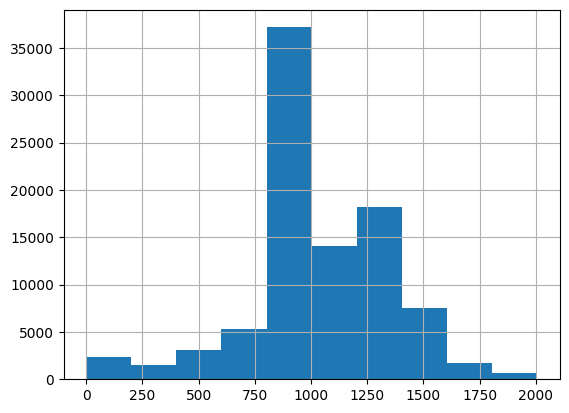

In [32]:
df_timedelta["deltadays"].hist()

<Axes: >

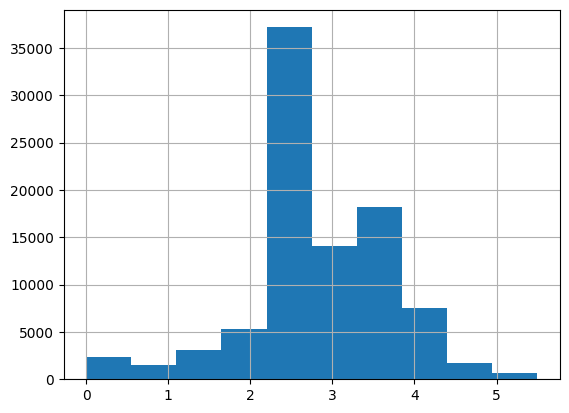

In [ ]:
df_timedelta["deltadays"].apply(lambda x: float(x) / 365).hist()

<Axes: xlabel='deltadays', ylabel='Density'>

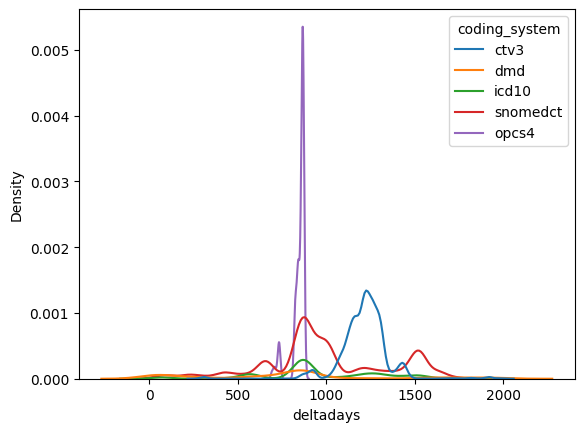

In [ ]:
sns.kdeplot(data=df_timedelta, x="deltadays", hue="coding_system")

<Axes: xlabel='deltadays', ylabel='coding_system'>

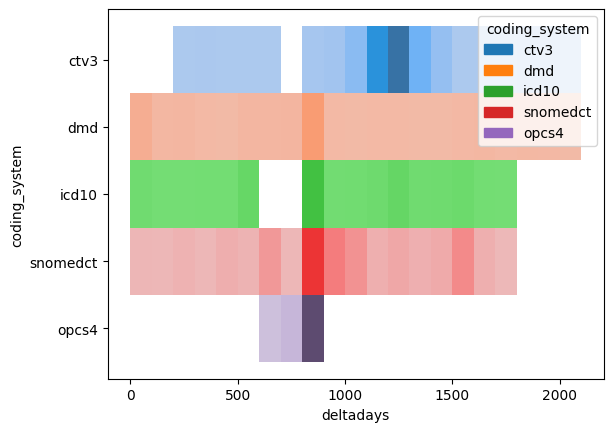

In [ ]:
sns.histplot(
    data=df_timedelta,
    x="deltadays",
    hue="coding_system",
    binwidth=100,
    y="coding_system",
)

_N.B: No BNF since BNF codelists can't be used in OpenSAFELY_

## Was there a newer version available at time of use?

In [ ]:
df_newer_available = df_timedelta[
    [
        "codelist_version_slug",
        "codelist_slug",
        "created_at_codelist_version",
        "created_at_job",
        "status_codelist_version",
        "variable_id",
        "sha",
    ]
]
df_newer_available = df_newer_available.merge(
    df_codelist_versions.reset_index(), on="codelist_slug", suffixes=["", "_newer"]
)
df_newer_available = df_newer_available[
    (df_newer_available.codelist_version_slug != df_newer_available.slug)
    & (df_newer_available.created_at_codelist_version < df_newer_available.created_at)
]
df_newer_available["newer_available"] = (
    df_newer_available.created_at_job > df_newer_available.created_at
)

In [ ]:
df_newer_available["job_variable_id"] = (
    df_newer_available["sha"] + "/" + df_newer_available["variable_id"].astype(str)
)

In [63]:
df_newer_available.groupby(["newer_available"])["job_variable_id"].nunique()

newer_available
False    2900
True     3542
Name: job_variable_id, dtype: int64

In [ ]:
df_newer_available[df_newer_available.newer_available].groupby(["status"])[
    "job_variable_id"
].nunique()

status
published       2090
under review    1540
Name: job_variable_id, dtype: int64

## How often are "out of date"* codelist versions used?

_ * if a new version of the codelist had been created at job urn time would there have been new codes? _

N.B: A bit of uncertainty in these results, uses `compatible_release` feature of OpenCodelists which was introduced at end of 2022.


In [ ]:
coding_system_release_dates = json.load(
    Path("../data/coding_system_release_dates.json").open()
)
version_compatible_release_dates = json.load(Path("../data/version_compat.json").open())
version_compatible_release_dates = {
    normalised_slug: v
    for k, v in version_compatible_release_dates.items()
    if (normalised_slug := normalised_version_slugs.get(k))
}

In [70]:
len(version_compatible_release_dates)

4595

In [ ]:
# find the valid_from date of the *next* coding system release after the latest compatible one
version_out_of_date_at = []
for (
    codelist_version_slug,
    compatibility_dates,
) in version_compatible_release_dates.items():
    last_compatible_date = max(compatibility_dates)
    coding_system = None
    for _c in codelists:
        if codelist_version_slug.startswith(_c["slug"]):
            coding_system = _c["coding_system"]
            break
    # None == we're already at the latest version
    best_before_date = min(
        [
            _d
            for _d in coding_system_release_dates[coding_system]
            if _d > last_compatible_date
        ]
        or [None]  # type: ignore
    )
    version_out_of_date_at.append(
        {
            "codelist_version_slug": codelist_version_slug,
            "best_before_date": best_before_date,
        }
    )
df_best_before_date = pd.DataFrame(version_out_of_date_at).set_index(
    "codelist_version_slug"
)

In [ ]:
# No best before - therefore fully up to date at time of extract
df_best_before_date.best_before_date.isnull().value_counts()

best_before_date
False    3547
True     1048
Name: count, dtype: int64

In [99]:
# codelists used after expiry
df_used_after_expiry = (
    df_job[df_job.status == "succeeded"]
    .merge(df_jobs_variables, left_index=True, right_on="sha")
    .merge(df_variables_codelists, on="variable_id")
    .merge(
        df_codelist_versions,
        left_on="codelist_version_slug",
        right_index=True,
        suffixes=["_job", "codelist_version"],
    )
    .merge(df_codelists, left_on="codelist_slug", right_index=True)
    .merge(df_best_before_date, left_on="codelist_version_slug", right_index=True)
)
df_used_after_expiry["used_after_expiry"] = pd.to_datetime(
    df_used_after_expiry.created_at_job, format="ISO8601", utc=True
) > pd.to_datetime(df_used_after_expiry.best_before_date, yearfirst=True, utc=True)

In [101]:
df_used_after_expiry.used_after_expiry.value_counts()

used_after_expiry
True     14577
False      431
Name: count, dtype: int64

In [102]:
df_used_after_expiry[df_used_after_expiry.used_after_expiry]

,url,created_at_job,status_job,sha,variable_id,codelist_version_slug,codelist_slug,tag,hash,created_atcodelist_version,...,statuscodelist_version,creation_method,clone_source_creation_method,name,owner,coding_system,created_at,updated_at_y,best_before_date,used_after_expiry
34,https://github.com/opensafely/openprompt_healt...,2023-06-26 17:08:11,succeeded,357305fccaa669f43825b029766e1de349735fba,887,opensafely/assessment-instruments-and-outcome-...,opensafely/assessment-instruments-and-outcome-...,None,79c0fa8a,2021-01-27 10:24:53.155055+00:00,...,published,Builder,None,Assessment instruments and outcome measures fo...,OpenSAFELY,snomedct,2021-01-27 10:24:53.152644+00:00,2021-01-27 10:30:12.531280+00:00,2022-10-05,True
35,https://github.com/opensafely/openprompt_healt...,2023-06-26 17:08:11,succeeded,357305fccaa669f43825b029766e1de349735fba,887,opensafely/nice-managing-the-long-term-effects...,opensafely/nice-managing-the-long-term-effects...,None,64f1ae69,2021-01-13 17:53:22.588043+00:00,...,published,Builder,None,NICE managing the long-term effects of COVID-19,OpenSAFELY,snomedct,2021-01-13 17:53:22.586396+00:00,2021-01-13 18:28:23.799324+00:00,2022-10-05,True
36,https://github.com/opensafely/openprompt_healt...,2023-06-26 17:08:11,succeeded,357305fccaa669f43825b029766e1de349735fba,887,opensafely/referral-and-signposting-for-long-c...,opensafely/referral-and-signposting-for-long-c...,None,12d06dc0,2021-01-27 10:18:29.562833+00:00,...,published,Builder,None,Referral and signposting for long COVID,OpenSAFELY,snomedct,2021-01-27 10:18:29.559834+00:00,2021-01-27 10:23:46.137139+00:00,2022-10-05,True
37,https://github.com/opensafely/openprompt_healt...,2023-06-26 17:08:11,succeeded,357305fccaa669f43825b029766e1de349735fba,891,opensafely/assessment-instruments-and-outcome-...,opensafely/assessment-instruments-and-outcome-...,None,79c0fa8a,2021-01-27 10:24:53.155055+00:00,...,published,Builder,None,Assessment instruments and outcome measures fo...,OpenSAFELY,snomedct,2021-01-27 10:24:53.152644+00:00,2021-01-27 10:30:12.531280+00:00,2022-10-05,True
38,https://github.com/opensafely/openprompt_healt...,2023-06-26 17:08:11,succeeded,357305fccaa669f43825b029766e1de349735fba,891,opensafely/nice-managing-the-long-term-effects...,opensafely/nice-managing-the-long-term-effects...,None,64f1ae69,2021-01-13 17:53:22.588043+00:00,...,published,Builder,None,NICE managing the long-term effects of COVID-19,OpenSAFELY,snomedct,2021-01-13 17:53:22.586396+00:00,2021-01-13 18:28:23.799324+00:00,2022-10-05,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91351,https://github.com/opensafely/metformin_covid,2025-10-17 12:38:23,succeeded,d591f69e79c8ba1ccbc790ee531fec850dc95268,4633,user/alex-walker/post-viral-syndrome/70708fd6,user/alex-walker/post-viral-syndrome,None,70708fd6,2021-04-09 10:26:42.106642+00:00,...,published,Builder,None,Post viral syndrome,alex-walker,snomedct,2021-04-09 10:26:42.098845+00:00,2021-04-09 10:26:42.098927+00:00,2022-10-05,True
91352,https://github.com/opensafely/metformin_covid,2025-10-17 12:38:23,succeeded,d591f69e79c8ba1ccbc790ee531fec850dc95268,4635,user/alex-walker/post-viral-syndrome/70708fd6,user/alex-walker/post-viral-syndrome,None,70708fd6,2021-04-09 10:26:42.106642+00:00,...,published,Builder,None,Post viral syndrome,alex-walker,snomedct,2021-04-09 10:26:42.098845+00:00,2021-04-09 10:26:42.098927+00:00,2022-10-05,True
91355,https://github.com/opensafely/metformin_covid,2025-10-17 12:38:23,succeeded,d591f69e79c8ba1ccbc790ee531fec850dc95268,4640,user/RochelleKnight/pregnancy_and_birth_snomed...,user/RochelleKnight/pregnancy_and_birth_snomed,None,1d46bcb3,2021-11-18 15:26:16.598102+00:00,...,under review,Builder,None,pregnancy_and_birth_SNOMED,RochelleKnight,snomedct,2021-11-18 15:26:16.594761+00:00,2021-11-18 16:14:44.439067+00:00,2022-10-05,True
91357,https://github.com/opensafely/metformin_covid,2025-10-17 12:38:23,succeeded,d591f69e79c8ba1ccbc790ee531fec850dc95268,4641,us

In [104]:
df_used_after_expiry.groupby("coding_system").used_after_expiry.value_counts()

coding_system  used_after_expiry
dmd            True                   272
               False                   16
icd10          True                   636
               False                  383
snomedct       True                 13669
               False                   32
Name: count, dtype: int64

## Can we use version compatibility dates to derive most recent "true" update date for a codelist version

In [118]:
def _derive_true_updated_at(row):
    compatibility_dates = version_compatible_release_dates.get(
        row["codelist_version_slug"]
    )
    if not compatibility_dates or compatibility_dates == ["1900-01-01"]:
        return row["updated_at"]
    return max([cd for cd in compatibility_dates if cd < row["created_at_job"]])


df_true_updated_at = (
    df_job[df_job.status == "succeeded"]
    .merge(df_jobs_variables, left_index=True, right_on="sha")
    .merge(df_variables_codelists, on="variable_id")
    .merge(
        df_codelist_versions,
        left_on="codelist_version_slug",
        right_index=True,
        suffixes=["_job", "_codelist_version"],
    )
    .merge(
        df_codelists,
        left_on="codelist_slug",
        right_index=True,
        suffixes=["", "_codelist"],
    )
)

df_true_updated_at["true_updated_at"] = df_true_updated_at.apply(
    lambda x: _derive_true_updated_at(x), axis=1
)

df_true_updated_at["timedelta"] = pd.to_datetime(
    df_true_updated_at.created_at_job, format="ISO8601", utc=True
) - pd.to_datetime(df_true_updated_at.true_updated_at, format="ISO8601", utc=True)
df_true_updated_at["deltadays"] = df_true_updated_at["timedelta"].apply(
    lambda x: x.days
)

<Axes: xlabel='deltadays', ylabel='Count'>

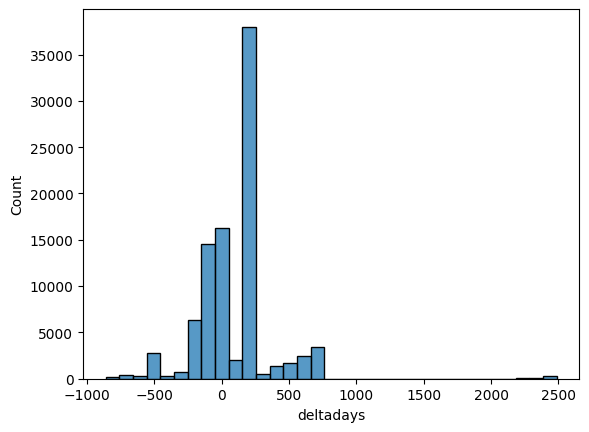

In [120]:
sns.histplot(df_true_updated_at["deltadays"], binwidth=100)